1. Daily Returns (All 40 Schemes)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [7]:
nav_df = pd.read_csv('../data/processed/clean_nav_history.csv')
nav_df.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [8]:
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code' , 'date'])
nav_df['daily_returns'] = nav_df.groupby('amfi_code')['nav'].pct_change()

In [9]:
nav_df["daily_returns"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_returns, dtype: float64

2. CAGR (1Y / 3Y / 5Y)

In [10]:
nav_pivot = nav_df.pivot(index='date', columns='amfi_code', values='nav')
print(nav_pivot.shape) 

(1150, 40)


In [11]:
def cagr(nav_series, years):
    nav_series = nav_series.dropna()
    lookback = int(252 * years)
    if len(nav_series) < lookback:
        return np.nan
    start = nav_series.iloc[-lookback]
    end = nav_series.iloc[-1]
    return (end / start) ** (1 / years) - 1

cagr_table = pd.DataFrame(index=nav_pivot.columns)
cagr_table['CAGR_1yr'] = [cagr(nav_pivot[f], 1) for f in nav_pivot.columns]
cagr_table['CAGR_3yr'] = [cagr(nav_pivot[f], 3) for f in nav_pivot.columns]
cagr_table['CAGR_5yr'] = [cagr(nav_pivot[f], 5) for f in nav_pivot.columns]

print(cagr_table.round(4))

           CAGR_1yr  CAGR_3yr  CAGR_5yr
amfi_code                              
100016      -0.0331   -0.0003       NaN
100025       0.0250    0.0461       NaN
100033       0.4773    0.3363       NaN
101206       0.4509    0.3253       NaN
101207      -0.2424   -0.0270       NaN
101208       0.0685    0.0608       NaN
102885       0.1832    0.1752       NaN
102886      -0.1323   -0.0183       NaN
102887       0.1273    0.2566       NaN
118632       0.2178    0.1809       NaN
118633       0.2841    0.1813       NaN
118634       0.2237    0.0758       NaN
118635       0.2200    0.1624       NaN
118636       0.1062    0.0415       NaN
119092       0.0340    0.0056       NaN
119093       0.1979    0.2058       NaN
119094       0.3092    0.3607       NaN
119095      -0.4542   -0.1107       NaN
119120       0.0572    0.0561       NaN
119551       0.4888    0.2773       NaN
119552       0.0825    0.1538       NaN
119598       0.8453    0.2781       NaN
119599       0.1191   -0.0069       NaN


In [12]:
ret_pivot = nav_df.pivot(index='date', columns='amfi_code', values='daily_returns')
print(ret_pivot.shape) 

(1150, 40)


In [13]:
Rf_daily = 0.065 / 252  

sharpe = {}
for fund in ret_pivot.columns:
    r = ret_pivot[fund].dropna()
    excess = r - Rf_daily
    sharpe[fund] = (excess.mean() / r.std()) * np.sqrt(252)

sharpe_series = pd.Series(sharpe, name='Sharpe_Ratio').sort_values(ascending=False)
print(sharpe_series)

148567    1.448291
120843    1.306744
148569    1.234930
119551    1.208267
120505    1.180101
149323    1.132122
100033    1.093699
118632    1.081659
101206    1.027213
120504    1.026524
119094    0.998231
119552    0.953279
149324    0.949796
119598    0.945308
148568    0.926287
102885    0.817099
120503    0.797973
125497    0.775790
118635    0.664857
120506    0.648879
118633    0.645207
102887    0.619518
120507    0.495723
120841    0.494273
149322    0.464037
118634    0.448434
125498    0.300612
101207    0.162661
119093    0.129614
120842    0.076000
119092    0.030785
119599   -0.057187
119095   -0.075974
120844   -0.088747
100016   -0.201517
102886   -0.205832
119120   -0.226575
118636   -0.356630
100025   -0.567095
101208   -0.815567
Name: Sharpe_Ratio, dtype: float64


In [14]:
sortino = {}
for fund in ret_pivot.columns:
    r = ret_pivot[fund].dropna()
    excess = r - Rf_daily
    downside = r[r < 0].std() 
    sortino[fund] = (excess.mean() / downside) * np.sqrt(252)

sortino_series = pd.Series(sortino, name='Sortino_Ratio').sort_values(ascending=False)
print(sortino_series)

148567    2.385644
120843    2.364320
148569    2.146914
119551    2.140267
120505    2.029353
149323    1.875101
118632    1.850133
100033    1.829134
120504    1.805294
101206    1.799563
119094    1.703797
119598    1.675317
148568    1.632741
149324    1.619793
119552    1.609776
102885    1.435742
120503    1.337943
125497    1.330651
118633    1.154476
118635    1.137977
120506    1.095895
102887    1.088755
120507    1.052124
120841    0.862574
149322    0.762129
118634    0.746015
125498    0.508813
101207    0.276644
119093    0.221087
120842    0.124693
119092    0.052574
119599   -0.094387
119095   -0.128186
120844   -0.187723
102886   -0.347222
100016   -0.351047
119120   -0.376767
118636   -0.613525
100025   -0.941821
101208   -1.681038
Name: Sortino_Ratio, dtype: float64


In [33]:
bench_df = pd.read_csv('../data/processed/clean_benchmark_indices.csv')
print(bench_df.head())       
print(bench_df.index.dtype)  

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
int64


In [34]:

bench_df['date'] = pd.to_datetime(bench_df['date'])
bench_df = bench_df.sort_values('date')

bench_df = bench_df.set_index('date')

bench_ret = bench_df['close_value'].pct_change().dropna()

print(bench_ret.head())
print(bench_ret.index.dtype) 

date
2022-01-03    -0.869574
2022-01-03     3.261121
2022-01-03    -0.850741
2022-01-03    11.251899
2022-01-03    -0.165437
Name: close_value, dtype: float64
datetime64[ns]


In [ ]:
from scipy import stats

benchmark = pd.read_csv('../data/processed/clean_benchmark_indices.csv')
benchmark['date'] = pd.to_datetime(benchmark['date'])


nifty50 = benchmark[benchmark['index_name'] == 'NIFTY50'].copy()
nifty50 = nifty50.sort_values('date').set_index('date')
nifty50_ret = nifty50['close_value'].pct_change().dropna()
nifty50_ret = nifty50_ret[~nifty50_ret.index.duplicated(keep='first')]

print("Nifty 50 returns shape:", nifty50_ret.shape)

alpha_beta = {}

for fund in ret_pivot.columns:
    r = ret_pivot[fund].dropna()
    r = r[~r.index.duplicated(keep='first')]
    
    aligned = pd.concat([nifty50_ret, r], axis=1, join='inner').dropna()
    aligned.columns = ['benchmark', 'fund']
    
    if len(aligned) < 30:
        continue
    
    x = aligned['benchmark'].values
    y = aligned['fund'].values
    
    slope, intercept, r_val, p_val, _ = stats.linregress(x, y)
    
    alpha_beta[fund] = {
        'Alpha': round(intercept * 252, 4),
        'Beta': round(slope, 4),
        'R_squared': round(r_val**2, 4)
    }

ab_df = pd.DataFrame(alpha_beta).T
ab_df.to_csv('../data/processed/alpha_beta.csv')
print("\n=== Alpha Beta Results ===")
print(ab_df.sort_values('Alpha', ascending=False).round(4))

Nifty 50 returns shape: (1149,)

=== Alpha Beta Results ===
         Alpha    Beta  R_squared
119598  0.3011  0.0743     0.0014
149324  0.2982  0.1326     0.0047
120505  0.2930 -0.0174     0.0001
148569  0.2835 -0.0102     0.0001
120843  0.2728 -0.0087     0.0001
100033  0.2723 -0.0112     0.0001
148567  0.2712 -0.0281     0.0007
149323  0.2658  0.0035     0.0000
119094  0.2600 -0.0599     0.0016
119551  0.2322 -0.0560     0.0028
118632  0.2173  0.0364     0.0011
101206  0.2139  0.0338     0.0009
120504  0.2121  0.0170     0.0002
148568  0.2079  0.0001     0.0000
119552  0.1983 -0.0199     0.0003
125497  0.1789 -0.0055     0.0000
118634  0.1780  0.0091     0.0000
120503  0.1759 -0.0041     0.0000
102885  0.1699 -0.0019     0.0000
120506  0.1628  0.0477     0.0016
102887  0.1618  0.0401     0.0011
118633  0.1550  0.0132     0.0001
118635  0.1516 -0.0138     0.0002
149322  0.1313  0.0148     0.0002
120841  0.1307  0.0417     0.0016
125498  0.1206 -0.0185     0.0002
101207  0.1082 -0.0599

In [40]:
def max_drawdown(nav_series):
    nav_s = nav_series.dropna()
    rolling_max = nav_s.cummax()
    drawdown = nav_s / rolling_max - 1
    mdd = drawdown.min()
    end_date = drawdown.idxmin()
    start_date = nav_s[:end_date].idxmax()
    return mdd, start_date, end_date

mdd_results = {}
for fund in nav_pivot.columns:
    mdd, s, e = max_drawdown(nav_pivot[fund])
    mdd_results[fund] = {
        'Max_Drawdown': mdd,
        'Peak_Date': s,
        'Trough_Date': e
    }

mdd_df = pd.DataFrame(mdd_results).T
print(mdd_df.sort_values('Max_Drawdown').round(4))

       Max_Drawdown            Peak_Date          Trough_Date
119599    -0.525742  2023-01-17 00:00:00  2025-10-28 00:00:00
119095    -0.516778  2025-05-22 00:00:00  2026-05-11 00:00:00
101207    -0.354469  2024-11-21 00:00:00  2026-05-11 00:00:00
149324    -0.311719  2024-05-03 00:00:00  2025-01-03 00:00:00
119598     -0.28706  2024-08-28 00:00:00  2025-05-14 00:00:00
102886    -0.280011  2025-01-07 00:00:00  2026-04-27 00:00:00
100016    -0.247344  2022-03-30 00:00:00  2022-09-15 00:00:00
120842    -0.240035  2023-11-09 00:00:00  2024-10-17 00:00:00
118634    -0.233449  2025-04-09 00:00:00  2026-02-20 00:00:00
119093    -0.217514  2022-02-24 00:00:00  2023-05-22 00:00:00
102887    -0.215398  2022-01-03 00:00:00  2022-07-04 00:00:00
125498    -0.211173  2025-04-04 00:00:00  2025-09-12 00:00:00
119094    -0.209609  2022-04-14 00:00:00  2022-08-11 00:00:00
120506    -0.198257  2023-03-31 00:00:00  2023-08-14 00:00:00
118633    -0.186297  2023-10-30 00:00:00  2024-02-29 00:00:00
120505  

In [41]:
fund_master = pd.read_csv('../data/processed/clean_fund_master.csv') 
print(fund_master.columns)
print(fund_master.head())

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity

In [42]:
fund_master = fund_master[['amfi_code', 'expense_ratio_pct']].drop_duplicates()

scorecard = pd.DataFrame(index=nav_pivot.columns)
scorecard.index.name = 'amfi_code'
scorecard = scorecard.reset_index()
scorecard = scorecard.merge(fund_master, on='amfi_code', how='left')
scorecard = scorecard.set_index('amfi_code')

scorecard['CAGR_3yr'] = cagr_table['CAGR_3yr']
scorecard['Sharpe']   = sharpe_series
scorecard['Alpha']    = ab_df['Alpha']
scorecard['Max_DD']   = mdd_df['Max_Drawdown'].astype(float)

n = len(scorecard)

scorecard['R_cagr']    = scorecard['CAGR_3yr'].rank()
scorecard['R_sharpe']  = scorecard['Sharpe'].rank()
scorecard['R_alpha']   = scorecard['Alpha'].rank()
scorecard['R_expense'] = scorecard['expense_ratio_pct'].rank(ascending=False) 
scorecard['R_mdd']     = scorecard['Max_DD'].rank(ascending=False)            

scorecard['Score'] = (
    0.30 * scorecard['R_cagr']    +
    0.25 * scorecard['R_sharpe']  +
    0.20 * scorecard['R_alpha']   +
    0.15 * scorecard['R_expense'] +
    0.10 * scorecard['R_mdd']
) / n * 100

scorecard_out = scorecard[['Score', 'CAGR_3yr', 'Sharpe', 'Alpha', 'expense_ratio_pct', 'Max_DD']]
scorecard_out = scorecard_out.sort_values('Score', ascending=False)
scorecard_out.to_csv('../data/processed/fund_scorecard.csv')
print(scorecard_out.round(4))

             Score  CAGR_3yr  Sharpe   Alpha  expense_ratio_pct  Max_DD
amfi_code                                                              
120505     84.5000    0.3021  1.1801  0.2930               1.36 -0.1819
100033     82.0000    0.3363  1.0937  0.2723               1.38 -0.1622
119094     80.7500    0.3607  0.9982  0.2600               1.38 -0.2096
119598     78.8750    0.2781  0.9453  0.3011               1.43 -0.2871
148567     78.5000    0.3128  1.4483  0.2712               1.46 -0.1127
120843     76.0000    0.2566  1.3067  0.2728               1.45 -0.1297
149324     74.1875    0.2503  0.9498  0.2982               1.52 -0.3117
120504     73.5000    0.2837  1.0265  0.2121               0.80 -0.1259
119551     71.5625    0.2773  1.2083  0.2322               1.54 -0.1501
148569     70.1875    0.2332  1.2349  0.2835               1.60 -0.1640
101206     66.9375    0.3253  1.0272  0.2139               1.60 -0.1129
149323     66.7500    0.2424  1.1321  0.2658               1.61 

In [43]:
top5 = scorecard_out.head(5).index.tolist()
print(top5)

[120505, 100033, 119094, 119598, 148567]


In [44]:
cutoff = nav_pivot.index[-1] - pd.DateOffset(years=3)
nav3 = nav_pivot.loc[cutoff:, top5]
print("nav3 shape:", nav3.shape)

nav3 shape: (785, 5)


In [45]:
bench_reset = bench_df.reset_index()
nifty50 = bench_reset[bench_reset['index_name'] == 'NIFTY50'].set_index('date')['close_value']
nifty100_price = bench_reset[bench_reset['index_name'] == 'NIFTY100'].set_index('date')['close_value']


In [46]:
start = nav3.index.min()
end = nav3.index.max()
n50  = nifty50.loc[start:end]
n100 = nifty100_price.loc[start:end]


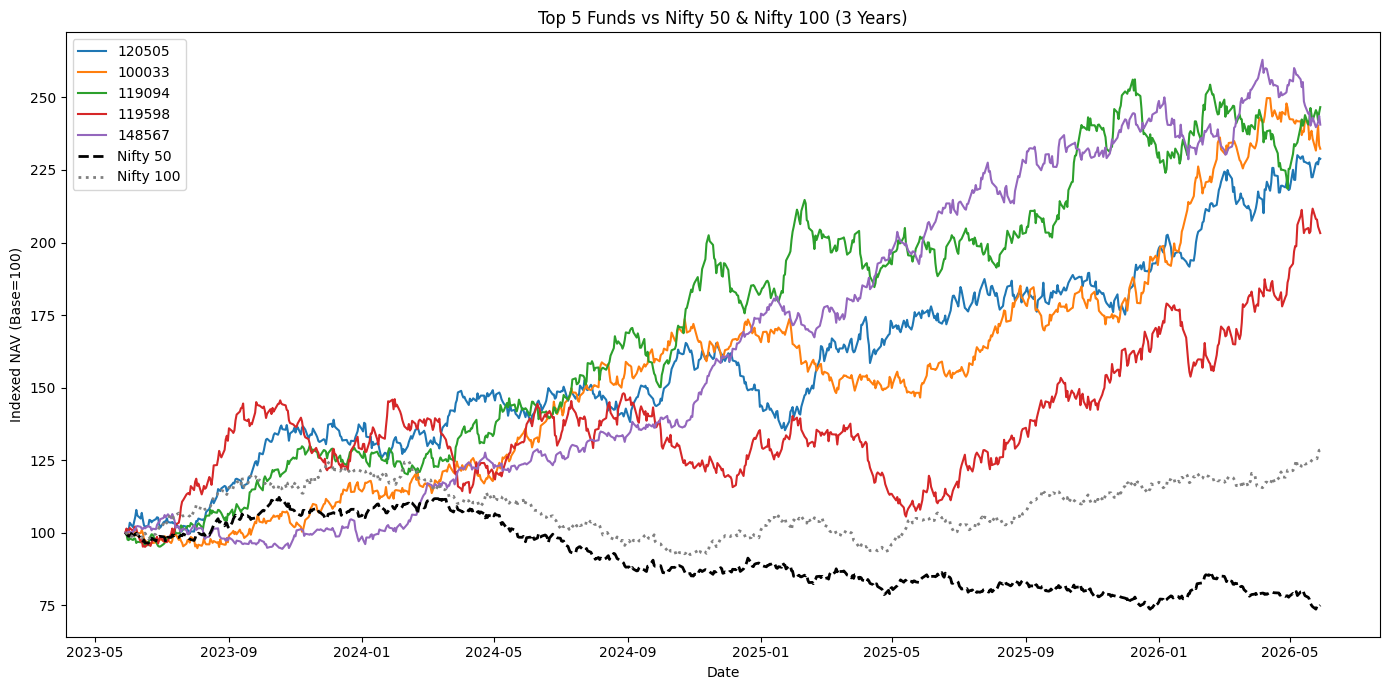

In [47]:
def norm(s): return s / s.iloc[0] * 100

plt.figure(figsize=(14, 7))
for fund in top5:
    plt.plot(norm(nav3[fund]), label=str(fund), linewidth=1.5)
plt.plot(norm(n50),  label='Nifty 50',  color='black', linewidth=2, linestyle='--')
plt.plot(norm(n100), label='Nifty 100', color='grey',  linewidth=2, linestyle=':')
plt.title('Top 5 Funds vs Nifty 50 & Nifty 100 (3 Years)')
plt.xlabel('Date')
plt.ylabel('Indexed NAV (Base=100)')
plt.legend()
plt.tight_layout()
plt.savefig('../charts/benchmark_comparison.png', dpi=150)
plt.show()

In [48]:
bench_ret_3 = n100.pct_change().dropna()

print("Tracking Error vs Nifty 100:")
for fund in top5:
    fr = nav3[fund].pct_change().dropna()
    common = fr.index.intersection(bench_ret_3.index)
    te = (fr.loc[common] - bench_ret_3.loc[common]).std() * np.sqrt(252)
    print(f"  {fund}: {te:.4f}")

Tracking Error vs Nifty 100:
  120505: 0.2327
  100033: 0.2250
  119094: 0.2398
  119598: 0.2867
  148567: 0.1880
